In [1]:
import pandas as pd
import os
import shutil
import seaborn as sns
from matplotlib import pyplot as plt
from IPython.display import display
INPUT_DIR = './NCT00981058_trial_data/jfcc_deid_ctrl_trt'
OUTPUT_DIR = './dataset_raw/real_NCT00981058/'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
else:
    shutil.rmtree(OUTPUT_DIR)
    os.makedirs(OUTPUT_DIR)

In [2]:
data_raw_traj = pd.read_sas(os.path.join(INPUT_DIR, 'adae.sas7bdat'))
data_raw_subj = pd.read_sas(os.path.join(INPUT_DIR, 'adsl.sas7bdat'))
data_raw_mh = pd.read_sas(os.path.join(INPUT_DIR, 'admh.sas7bdat'))
data_raw_lb = pd.read_sas(os.path.join(INPUT_DIR, 'adlb.sas7bdat'))
data_raw_vs = pd.read_sas(os.path.join(INPUT_DIR, 'advs.sas7bdat'))


## Check and clean the survival data

In [3]:
data_raw_traj['SUBJID'].nunique()

537

In [4]:
data_raw_traj['TRTEMFL'].value_counts(dropna=False)

TRTEMFL
b'Y'    6379
NaN      165
Name: count, dtype: int64

In [5]:
data_raw_traj['AECYC'].value_counts(dropna=False)

AECYC
1.0    1758
2.0    1225
4.0    1046
3.0    1030
5.0     743
6.0     577
NaN     165
Name: count, dtype: int64

In [6]:
list(data_raw_traj.columns)

['STUDYID',
 'USUBJID',
 'SUBJID',
 'SITEID',
 'AGECAT1',
 'AGECAT1N',
 'AGECAT2',
 'AGECAT2N',
 'AGECAT3',
 'AGECAT3N',
 'SEX',
 'SEXN',
 'RACEGR1',
 'RACEGR1N',
 'COUNTRY',
 'COUNGR1',
 'COUNGR1N',
 'COUNGR2',
 'COUNGR2N',
 'COUNGR3',
 'COUNGR3N',
 'COUNGR4',
 'COUNGR4N',
 'COUNGR5',
 'COUNGR5N',
 'COUNGR6',
 'COUNGR6N',
 'COUNGR7',
 'COUNGR7N',
 'COUNGR8',
 'COUNGR8N',
 'COUNGR9',
 'COUNGR9N',
 'COUGR10',
 'COUGR10N',
 'COUGR11',
 'COUGR11N',
 'COUGR12',
 'COUGR12N',
 'COUGR13',
 'COUGR13N',
 'COUGR14',
 'COUGR14N',
 'COUGR15',
 'COUGR15N',
 'COUGR16',
 'COUGR16N',
 'COUGR17',
 'COUGR17N',
 'COUGR18',
 'COUGR18N',
 'COUGR19',
 'COUGR19N',
 'COUGR20',
 'COUGR20N',
 'COUGR21',
 'COUGR21N',
 'COUGR22',
 'COUGR22N',
 'COUGR23',
 'COUGR23N',
 'COUGR24',
 'COUGR24N',
 'COUGR25',
 'COUGR25N',
 'COUGR26',
 'COUGR26N',
 'SCRFL',
 'RANDFL',
 'SAFFL',
 'ITTFL',
 'PPROTFL',
 'MPVFL',
 'CMANTCFL',
 'MPFL',
 'EGFKTIFL',
 'BSABL',
 'ECOGBL',
 'ECOCAT1',
 'ECOCAT1N',
 'ECOCAT2',
 'ECOCAT2N',
 'SMKB

In [7]:
data_raw_traj.groupby(
    ['AEBODSYS']
)['AEDECOD'].unique()

AEBODSYS
b'BLOOD AND LYMPHATIC SYSTEM DISORDERS'                                   [b'Anaemia', b'Neutropenia', b'Thrombocytopeni...
b'CARDIAC DISORDERS'                                                      [b'Atrial fibrillation', b'Atrial tachycardia'...
b'CONGENITAL, FAMILIAL AND GENETIC DISORDERS'                                                    [b'Epidermolysis bullosa']
b'EAR AND LABYRINTH DISORDERS'                                            [b'Tinnitus', b'Deafness bilateral', b'Vertigo...
b'ENDOCRINE DISORDERS'                                                    [b'Adrenal insufficiency', b'Hypothyroidism', ...
b'EYE DISORDERS'                                                          [b'Lacrimation increased', b'Conjunctival haem...
b'GASTROINTESTINAL DISORDERS'                                             [b'Diarrhoea', b'Nausea', b'Vomiting', b'Const...
b'GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS'                   [b'Chest pain', b'Pyrexia', b'Fatigue', b'Oede...

In [8]:
pd.crosstab(
    data_raw_traj['TRTEMFL'].astype(str),
    data_raw_traj['AERELC'].astype(str)
)

AERELC,DEFINITE/CERTAIN,NOT LIKELY,POSSIBLE,PROBABLE,UNRELATED
TRTEMFL,,,,,
Y,1426,412,1433,1325,1783
nan,6,4,3,3,149


In [9]:
data_raw_traj.groupby(
    ['AERELI','AERELG','AERELC']
)['AEREL'].value_counts()

AERELI         AERELG               AERELC               AEREL         
b'NOT LIKELY'  b'DEFINITE/CERTAIN'  b'DEFINITE/CERTAIN'  b'RELATED'           1
               b'NOT LIKELY'        b'NOT LIKELY'        b'NOT RELATED'       3
               b'POSSIBLE'          b'DEFINITE/CERTAIN'  b'RELATED'           1
               b'PROBABLE'          b'PROBABLE'          b'RELATED'           1
               b'UNRELATED'         b'UNRELATED'         b'NOT RELATED'       3
b'UNRELATED'   b'DEFINITE/CERTAIN'  b'DEFINITE/CERTAIN'  b'RELATED'        1101
                                    b'NOT LIKELY'        b'RELATED'          12
                                    b'POSSIBLE'          b'RELATED'           6
                                    b'PROBABLE'          b'RELATED'           7
                                    b'UNRELATED'         b'RELATED'          42
               b'NOT LIKELY'        b'DEFINITE/CERTAIN'  b'RELATED'          39
                                    b'NOT LIKELY

In [10]:
data_raw_traj_rel = data_raw_traj.loc[
    (data_raw_traj['AEREL'] == b'RELATED') &
    (data_raw_traj['AESDY'] >= 0) ,:
]

In [11]:
data_raw_traj_rel.groupby(
    ['AEBODSYS']
)['AEDECOD'].unique()

AEBODSYS
b'BLOOD AND LYMPHATIC SYSTEM DISORDERS'                                   [b'Anaemia', b'Neutropenia', b'Thrombocytopeni...
b'CARDIAC DISORDERS'                                                      [b'Cardiovascular insufficiency', b'Angina pec...
b'EAR AND LABYRINTH DISORDERS'                                            [b'Tinnitus', b'Vertigo', b'Deafness', b'Ototo...
b'EYE DISORDERS'                                                          [b'Lacrimation increased', b'Vision blurred', ...
b'GASTROINTESTINAL DISORDERS'                                             [b'Diarrhoea', b'Constipation', b'Abdominal pa...
b'GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS'                   [b'Chest pain', b'Pyrexia', b'Fatigue', b'Syst...
b'HEPATOBILIARY DISORDERS'                                                [b'Hepatocellular injury', b'Hyperbilirubinaem...
b'IMMUNE SYSTEM DISORDERS'                                                                       [b'Drug hypersensitivity']

In [12]:
data_raw_traj_rel['AESIFL'].value_counts(dropna=False)

AESIFL
NaN     4114
b'Y'     198
Name: count, dtype: int64

In [13]:
data_raw_traj_rel.loc[
    data_raw_traj_rel['AESIFL'] == b'Y',
    ['SUBJID','AEDECOD', 'AESDY','AEEDY','AETOXGR','AERELI','AERELG','AERELC','AEREL']
]

,SUBJID,AEDECOD,AESDY,AEEDY,AETOXGR,AERELI,AERELG,AERELC,AEREL
21,b'001-7882',b'Acne',50.0,NaN,b'1',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
37,b'006-7880',b'Pulmonary embolism',43.0,80.0,b'4',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
235,b'014-7884',b'Hypomagnesaemia',71.0,NaN,b'1',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
247,b'017-7886',b'Lacrimation increased',105.0,NaN,b'1',b'UNRELATED',b'PROBABLE',b'UNRELATED',b'RELATED'
284,b'018-7882',b'Acne',22.0,NaN,b'1',b'UNRELATED',b'UNRELATED',b'POSSIBLE',b'RELATED'
...,...,...,...,...,...,...,...,...,...
6373,b'722-7886',b'Hypomagnesaemia',51.0,77.0,b'1',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
6444,b'749-7886',b'Pruritus',41.0,NaN,b'1',b'UNRELATED',b'PROBABLE',b'PROBABLE',b'RELATED'
6445,b'749-7886',b'Rash',41.0,NaN,b'1',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
6478,b'782-7881',b'Hypomagnesaemia',35.0,NaN,b'1',b'UNRELATED',b'PROBABLE',b'PROBABLE',b'RELATED'


In [14]:
data_raw_traj_rel.loc[
    data_raw_traj_rel['AEDECOD'].isin(
        data_raw_traj_rel.loc[
            data_raw_traj_rel['AESIFL'] == b'Y','AEDECOD'
        ].unique()
    ),
    ['SUBJID','AEDECOD', 'AESDY','AEEDY','AETOXGR','AERELI','AERELG','AERELC','AEREL']

]

,SUBJID,AEDECOD,AESDY,AEEDY,AETOXGR,AERELI,AERELG,AERELC,AEREL
21,b'001-7882',b'Acne',50.0,NaN,b'1',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
37,b'006-7880',b'Pulmonary embolism',43.0,80.0,b'4',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
235,b'014-7884',b'Hypomagnesaemia',71.0,NaN,b'1',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
247,b'017-7886',b'Lacrimation increased',105.0,NaN,b'1',b'UNRELATED',b'PROBABLE',b'UNRELATED',b'RELATED'
284,b'018-7882',b'Acne',22.0,NaN,b'1',b'UNRELATED',b'UNRELATED',b'POSSIBLE',b'RELATED'
...,...,...,...,...,...,...,...,...,...
6373,b'722-7886',b'Hypomagnesaemia',51.0,77.0,b'1',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
6444,b'749-7886',b'Pruritus',41.0,NaN,b'1',b'UNRELATED',b'PROBABLE',b'PROBABLE',b'RELATED'
6445,b'749-7886',b'Rash',41.0,NaN,b'1',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
6478,b'782-7881',b'Hypomagnesaemia',35.0,NaN,b'1',b'UNRELATED',b'PROBABLE',b'PROBABLE',b'RELATED'


In [15]:
data_raw_traj_rel.loc[data_raw_traj_rel['AESIFL'] == b'Y',:].groupby(
    ['AEBODSYS']
)['AEDECOD'].unique()

AEBODSYS
b'BLOOD AND LYMPHATIC SYSTEM DISORDERS'                                         [b'Splenic infarction']
b'CARDIAC DISORDERS'                                     [b'Angina pectoris', b'Myocardial infarction']
b'EYE DISORDERS'                                      [b'Lacrimation increased', b'Vision blurred', ...
b'IMMUNE SYSTEM DISORDERS'                                                   [b'Drug hypersensitivity']
b'INFECTIONS AND INFESTATIONS'                                        [b'Cellulitis', b'Rash pustular']
b'INJURY, POISONING AND PROCEDURAL COMPLICATIONS'                        [b'Infusion related reaction']
b'INVESTIGATIONS'                                                        [b'Blood magnesium decreased']
b'METABOLISM AND NUTRITION DISORDERS'                                              [b'Hypomagnesaemia']
b'NERVOUS SYSTEM DISORDERS'                                             [b'Transient ischaemic attack']
b'RESPIRATORY, THORACIC AND MEDIASTINAL DISORDERS'     

In [16]:
sorted(data_raw_traj_rel.loc[data_raw_traj_rel['AESIFL'] == b'Y','AEDECOD'].unique())

[b'Acne',
 b'Angina pectoris',
 b'Blood magnesium decreased',
 b'Cellulitis',
 b'Deep vein thrombosis',
 b'Dermatitis acneiform',
 b'Drug hypersensitivity',
 b'Dry skin',
 b'Erythema',
 b'Hypomagnesaemia',
 b'Infusion related reaction',
 b'Lacrimation increased',
 b'Myocardial infarction',
 b'Nail discolouration',
 b'Nail disorder',
 b'Peripheral artery thrombosis',
 b'Peripheral ischaemia',
 b'Photosensitivity reaction',
 b'Pigmentation disorder',
 b'Pruritus',
 b'Pulmonary embolism',
 b'Rash',
 b'Rash generalised',
 b'Rash maculo-papular',
 b'Rash pustular',
 b'Skin exfoliation',
 b'Splenic infarction',
 b'Thrombosis',
 b'Transient ischaemic attack',
 b'Urticaria',
 b'Vision blurred',
 b'Visual impairment']

In [17]:
data_raw_traj[['SUBJID','AESDY','AEEDY','AETOXGR','AERELI','AERELG','AERELC','AEREL']]

,SUBJID,AESDY,AEEDY,AETOXGR,AERELI,AERELG,AERELC,AEREL
0,b'001-7881',15.0,29.0,b'2',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
1,b'001-7881',29.0,NaN,b'1',b'UNRELATED',b'UNRELATED',b'UNRELATED',b'NOT RELATED'
2,b'001-7881',30.0,31.0,b'2',b'UNRELATED',b'POSSIBLE',b'POSSIBLE',b'RELATED'
3,b'001-7881',44.0,53.0,b'3',b'UNRELATED',b'NOT LIKELY',b'NOT LIKELY',b'NOT RELATED'
4,b'001-7882',15.0,29.0,b'4',b'UNRELATED',b'PROBABLE',b'PROBABLE',b'RELATED'
...,...,...,...,...,...,...,...,...
6539,b'981-7886',2.0,NaN,b'1',b'UNRELATED',b'DEFINITE/CERTAIN',b'DEFINITE/CERTAIN',b'RELATED'
6540,b'981-7886',182.0,182.0,b'2',b'UNRELATED',b'UNRELATED',b'UNRELATED',b'NOT RELATED'
6541,b'981-7886',63.0,70.0,b'2',b'UNRELATED',b'UNRELATED',b'UNRELATED',b'NOT RELATED'
6542,b'981-7886',118.0,NaN,b'2',b'UNRELATED',b'UNRELATED',b'UNRELATED',b'NOT RELATED'


In [18]:
data_raw_traj['AETOXGR'].astype(float).describe()

count    6538.000000
mean        1.712909
std         0.836681
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         5.000000
Name: AETOXGR, dtype: float64

In [19]:
def get_max_grade_by_time(df):
    df_sorted = df.sort_values(['AESDY'])
    df_sorted['AETOXGR'] = df_sorted['AETOXGR'].astype(float)
    rows = []
    if 0 not in df_sorted['AESDY'].values:
        rows.append(
            {
                'AEDY': 0,
                'AETOXGR_max': 0
            }
        )

    for t in df_sorted['AESDY'].unique():
        df_sub = df_sorted.loc[df_sorted['AESDY'] <= t]
        max_grade = df_sub['AETOXGR'].max()
        rows.append(
            {
                'AEDY': t,
                'AETOXGR_max': max_grade
            }
        )
    
    return pd.DataFrame(rows)
data_raw_traj_ae_comb = data_raw_traj_rel.groupby(['SUBJID']).apply(get_max_grade_by_time).reset_index(level=[0])
data_raw_traj_ae_comb

/tmp/ipykernel_23295/1040666481.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_raw_traj_ae_comb = data_raw_traj_rel.groupby(['SUBJID']).apply(get_max_grade_by_time).reset_index(level=[0])


,SUBJID,AEDY,AETOXGR_max
0,b'001-7881',0.0,0.0
1,b'001-7881',15.0,2.0
2,b'001-7881',30.0,2.0
0,b'001-7882',0.0,0.0
1,b'001-7882',2.0,2.0
...,...,...,...
6,b'981-7886',63.0,3.0
7,b'981-7886',78.0,3.0
8,b'981-7886',90.0,3.0
9,b'981-7886',98.0,3.0


In [20]:
data_raw_traj_ae_comb['SUBJID'].nunique()

501

In [21]:
data_raw_traj_ae_comb.groupby('SUBJID')['AETOXGR_max'].max().value_counts().sort_index()

AETOXGR_max
1.0     59
2.0    179
3.0    189
4.0     64
5.0     10
Name: count, dtype: int64

<Axes: >

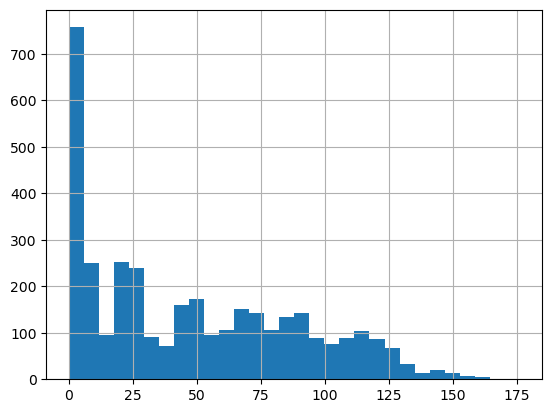

In [22]:
data_raw_traj_ae_comb['AEDY'].hist(bins=30)

In [23]:
onset_time_grades = data_raw_traj_ae_comb.groupby(['SUBJID','AETOXGR_max'])['AEDY'].min().reset_index()

/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='AETOXGR_max', ylabel='AEDY'>

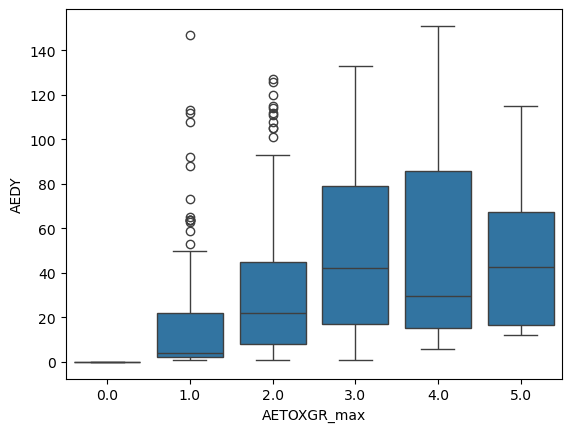

In [24]:
sns.boxplot(
    data=onset_time_grades,
    x='AETOXGR_max',
    y='AEDY'
)

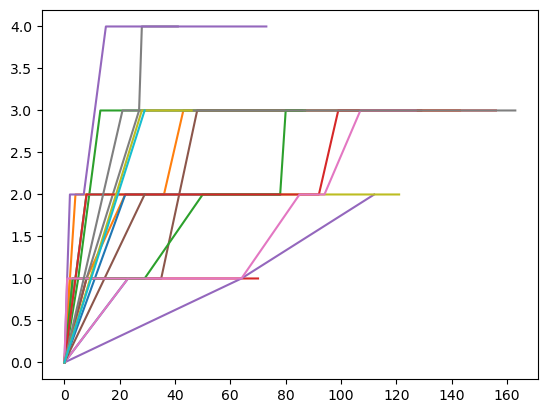

In [25]:
import numpy as np
fig, ax = plt.subplots(1,1)
for subj in np.random.choice(data_raw_traj_ae_comb['SUBJID'].unique(), 20):
    df_sub = data_raw_traj_ae_comb.loc[
        data_raw_traj_ae_comb['SUBJID'] == subj,:
    ]
    ax.plot(df_sub['AEDY'], df_sub['AETOXGR_max'])

In [26]:
df_interest_raw_traj = data_raw_traj_ae_comb.copy()

## Check demographic columns

In [27]:
assert data_raw_subj['SUBJID'].value_counts().max() == 1
data_raw_subj = data_raw_subj.set_index('SUBJID', drop=False)

In [28]:
assert data_raw_traj_ae_comb['SUBJID'].isin(
    data_raw_subj['SUBJID']
).all()

### Check key dates

In [29]:
(data_raw_subj['TRTEDT'] - data_raw_subj['TRTSDT']).describe()

count                  541
mean      83 days 23:49:21
std       42 days 05:24:58
min        0 days 00:00:00
25%       49 days 00:00:00
50%      105 days 00:00:00
75%      116 days 00:00:00
max      168 days 00:00:00
dtype: object

In [30]:
(data_raw_subj['CPSEDT'] - data_raw_subj['TRTEDT']).describe()

count                  532
mean      77 days 15:31:07
std      100 days 23:34:10
min        0 days 00:00:00
25%       28 days 18:00:00
50%       42 days 00:00:00
75%       84 days 06:00:00
max      784 days 00:00:00
dtype: object

In [31]:
end_eval_day = (data_raw_subj['CPSEDT'] - data_raw_subj['TRTSDT'])
end_eval_day.describe()

count                  532
mean     161 days 02:04:30
std      122 days 10:43:16
min        1 days 00:00:00
25%       81 days 12:00:00
50%      149 days 12:00:00
75%      200 days 06:00:00
max      934 days 00:00:00
dtype: object

In [32]:
data_raw_traj_ae_comb['end_eval_days'] = data_raw_traj_ae_comb['SUBJID'].map(
    end_eval_day.map(lambda x: x.days + 1)
)

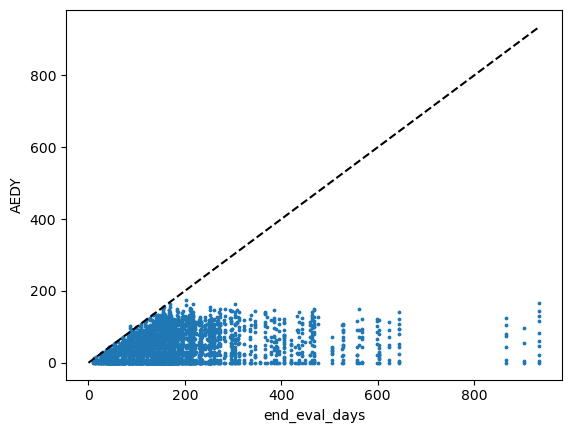

In [33]:
fig, ax = plt.subplots(1,1)

data_raw_traj_ae_comb.plot(
    kind='scatter',
    x='end_eval_days', 
    y='AEDY',
    ax=ax,
    s=3
)
min_ = data_raw_traj_ae_comb[['end_eval_days','AEDY']].min().min()
max_ = data_raw_traj_ae_comb[['end_eval_days','AEDY']].max().max()
ax.plot([min_, max_], [min_, max_], color='black', ls='--')

In [34]:
(data_raw_subj['DSSTDT'] - data_raw_subj['CPSEDT']).describe()

count                540
mean     0 days 00:00:00
std      0 days 00:00:00
min      0 days 00:00:00
25%      0 days 00:00:00
50%      0 days 00:00:00
75%      0 days 00:00:00
max      0 days 00:00:00
dtype: object

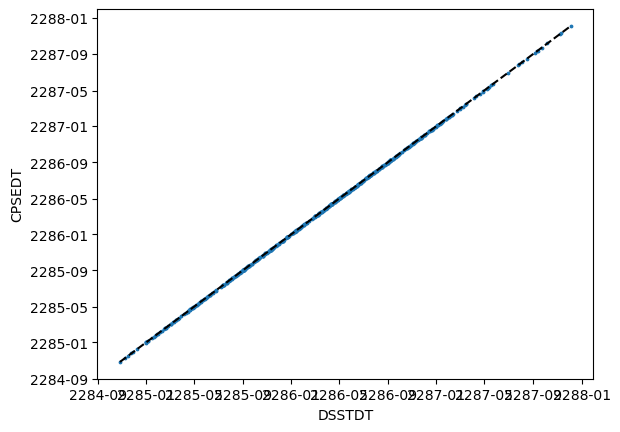

In [35]:
fig, ax = plt.subplots(1,1)

data_raw_subj.plot(
    kind='scatter',
    x='DSSTDT', 
    y='CPSEDT',
    ax=ax,
    s=3
)
min_ = data_raw_subj[['DSSTDT','CPSEDT']].min().min()
max_ = data_raw_subj[['DSSTDT','CPSEDT']].max().max()
ax.plot([min_, max_], [min_, max_], color='black', ls='--')

In [36]:
data_raw_traj_ae_comb.loc[
    data_raw_traj_ae_comb['AEDY'] > data_raw_traj_ae_comb['end_eval_days'],:
]

,SUBJID,AEDY,AETOXGR_max,end_eval_days
10,b'011-7808',87.0,3.0,86.0
11,b'011-7808',97.0,3.0,86.0
12,b'011-7808',101.0,3.0,86.0
4,b'623-7886',95.0,2.0,88.0


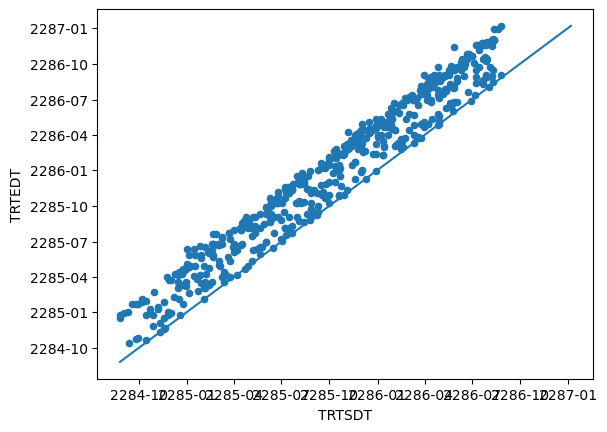

In [37]:
fig, ax = plt.subplots(1,1)
data_raw_subj.plot(
    kind='scatter',
    x='TRTSDT',
    y='TRTEDT',
    ax=ax
)

min_ = data_raw_subj[['TRTSDT','TRTEDT']].min().min()
max_ = data_raw_subj[['TRTSDT','TRTEDT']].max().max()
ax.plot([min_, max_], [min_, max_])


### Check missingness

<Axes: >

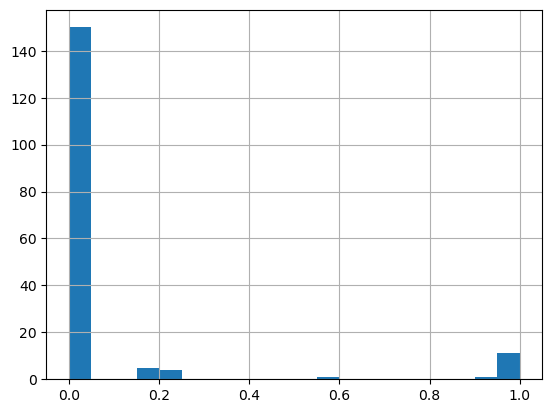

In [38]:
data_raw_subj.isna().mean(axis=0).hist(bins=20)

In [39]:
cols_non_sparse = data_raw_subj.columns[data_raw_subj.isna().mean(axis=0) < 0.1]
cols_sparse = data_raw_subj.columns[data_raw_subj.isna().mean(axis=0) >= 0.1]

In [40]:
data_raw_subj[cols_sparse].isna().mean(axis=0).sort_values()

DEATHDT     0.194900
PRMDTHN     0.194900
DEATH       0.194900
DEATHDTC    0.194900
DTHAUT      0.196721
DEATHLDY    0.204007
DEATHFDY    0.204007
DEATHFL     0.204007
SURFLUP     0.227687
CPTRTDT     0.571949
RACEOTH     0.921676
DTHAUTDT    0.981785
DSTERMTR    1.000000
INVNAM      1.000000
PRMDTH      1.000000
DSTERMST    1.000000
BRTHDTC     1.000000
SCRFREAS    1.000000
DSSTROTH    1.000000
DSTRROTH    1.000000
DTHCOMNT    1.000000
SITEID      1.000000
dtype: float64

<Axes: >

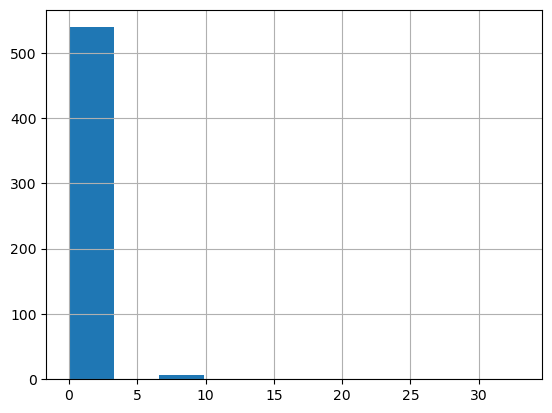

In [41]:
data_raw_subj[cols_non_sparse].isna().sum(axis=1).hist()

In [42]:
list(cols_non_sparse)

['STUDYID',
 'USUBJID',
 'SUBJID',
 'TRT01P',
 'TRT01PN',
 'TRT01A',
 'TRT01AN',
 'INVID',
 'RFSTDTC',
 'RFENDTC',
 'RANDNUM',
 'ICDT',
 'AGE',
 'AGEU',
 'AGEIC',
 'AGECAT1',
 'AGECAT1N',
 'AGECAT2',
 'AGECAT2N',
 'AGECAT3',
 'AGECAT3N',
 'SEX',
 'SEXN',
 'RACE',
 'RACEN',
 'ARACE',
 'RACEGR1',
 'RACEGR1N',
 'ETHNIC',
 'ETHNICN',
 'ARMCD',
 'ARM',
 'COUNTRY',
 'COUNGR1',
 'COUNGR1N',
 'COUNGR2',
 'COUNGR2N',
 'COUNGR3',
 'COUNGR3N',
 'COUNGR4',
 'COUNGR4N',
 'COUNGR5',
 'COUNGR5N',
 'COUNGR6',
 'COUNGR6N',
 'COUNGR7',
 'COUNGR7N',
 'COUNGR8',
 'COUNGR8N',
 'COUNGR9',
 'COUNGR9N',
 'COUGR10',
 'COUGR10N',
 'COUGR11',
 'COUGR11N',
 'COUGR12',
 'COUGR12N',
 'COUGR13',
 'COUGR13N',
 'COUGR14',
 'COUGR14N',
 'COUGR15',
 'COUGR15N',
 'COUGR16',
 'COUGR16N',
 'COUGR17',
 'COUGR17N',
 'COUGR18',
 'COUGR18N',
 'COUGR19',
 'COUGR19N',
 'COUGR20',
 'COUGR20N',
 'COUGR21',
 'COUGR21N',
 'COUGR22',
 'COUGR22N',
 'COUGR23',
 'COUGR23N',
 'COUGR24',
 'COUGR24N',
 'COUGR25',
 'COUGR25N',
 'COUGR26',
 

In [43]:
data_raw_subj['ADDCONFL'].value_counts()

ADDCONFL
b'N'    549
Name: count, dtype: int64

In [44]:
data_raw_subj['PLTCAT1'].value_counts(dropna=False)

PLTCAT1
b'< 350 x 10^9/L'     296
b'>= 350 x 10^9/L'    251
NaN                     2
Name: count, dtype: int64

In [45]:
cols_demo_days_interest = [
    'CPSEDT',
    'TRTSDT'
]
cols_demo_interest = [
    'AGE',
    'SEX',
    'RACE',
    'ETHNIC',
    'HISCYTFL',
    'DISSTGFL',
    'ECOGLGFL',
    # 'HEIGHTBL',
    # 'WEIGHTBL',
    'BSABL',
    'ECOGBL',
    'SMKB',
    'HISTOLG',
    'WBCCAT1',
    'HGBCAT1',
    'PLTCAT1',
    'BMIBL',
] + cols_demo_days_interest

In [46]:
list(set(data_raw_traj.columns) - set(data_raw_subj.columns))

['AEDECOD',
 'AEDMCFL',
 'TRTPN',
 'AERELCFL',
 'AEOUT',
 'CONSOCAT',
 'TRTAN',
 'AERELG',
 'AESEQ',
 'AERELGFL',
 'AEEDT',
 'AEBODSYS',
 'AESICAT',
 'AEACN',
 'RASHAEFL',
 'AEACN6',
 'AEREL',
 'AEACN5',
 'AERELFL',
 'AECYCDY',
 'AEEDY',
 'AEACN4',
 'AERELI',
 'AEACN2',
 'AESDT',
 'AEEDTF',
 'AECONTRT',
 'AESIFL',
 'AEACN3',
 'AECDY',
 'AEDCCFL',
 'APHASEN',
 'AEDCFL',
 'AESDY',
 'AESTDTC',
 'AESDTF',
 'AEACN1',
 'APHASE',
 'AESER',
 'TRTEMFL',
 'AEACND',
 'AERELIFL',
 'AETERM',
 'AETOXGR',
 'AEHLT',
 'AESHOSP',
 'AERELC',
 'CONSOFL',
 'AECYC',
 'TRTA',
 'AEHLGT',
 'AEENDTC',
 'TRTP',
 'AEACN7',
 'AEDMFL']

In [47]:
data_raw_subj[list(set(data_raw_subj.columns) - set(data_raw_traj.columns))].isna().mean().sort_values(ascending=False)

SCRFREAS    1.0
INVNAM      1.0
DSSTROTH    1.0
DTHCOMNT    1.0
DSTRROTH    1.0
           ... 
SDYSTAT     0.0
ARACE       0.0
DSSTFL      0.0
RFSTDTC     0.0
SCRFLFL     0.0
Length: 71, dtype: float64

In [48]:
cols_shared_demo_traj = list(set(data_raw_traj.columns).intersection(data_raw_subj.columns))
data_raw_subj[cols_shared_demo_traj].isna().mean().sort_values(ascending=False).head(30)

SITEID      1.000000
HISTOLG     0.012750
HISTOLGN    0.012750
BMIBL       0.007286
BMICAT1     0.007286
BMICAT1N    0.007286
RFGR1N      0.003643
WBCCAT1     0.003643
BSABL       0.003643
HGBCAT1     0.003643
PLTCAT1N    0.003643
RFGR1       0.003643
WBCCAT1N    0.003643
HGBCAT1N    0.003643
PLTCAT1     0.003643
ECOGBL      0.001821
SMKCAT1     0.001821
SMKB        0.001821
SMKBN       0.001821
ECOCAT2N    0.001821
ECOCAT2     0.001821
SMKCAT1N    0.001821
COUGR18N    0.000000
COUNGR8N    0.000000
COUNGR7     0.000000
COUGR12     0.000000
USUBJID     0.000000
COUGR10     0.000000
COUNGR7N    0.000000
COUNGR6     0.000000
dtype: float64

In [49]:
data_raw_subj['SUBJID'].nunique()

549

In [50]:
data_raw_subj['SUBJID'].value_counts().value_counts()

count
1    549
Name: count, dtype: int64

In [51]:
data_raw_subj['SCRFLFL'].value_counts()

SCRFLFL
b'N'    549
Name: count, dtype: int64

In [52]:
data_raw_subj['TRT01A'].value_counts(dropna=False)

TRT01A
b'B'    541
NaN       8
Name: count, dtype: int64

In [53]:
data_raw_subj['ARMCD'].value_counts()

ARMCD
b'B'    549
Name: count, dtype: int64

In [54]:
cols = [i for i in cols_demo_interest if i not in cols_demo_days_interest]
cols_demo_interest_numer = data_raw_subj[cols].select_dtypes("number").columns
cols_demo_interest_cat = [i for i in cols if i not in cols_demo_interest_numer]



In [55]:
df_interest_raw_demo = data_raw_subj[cols_demo_interest]

## Check medical history 

In [56]:
data_raw_mh.head()

,STUDYID,USUBJID,SUBJID,SITEID,AGECAT1,AGECAT1N,AGECAT2,AGECAT2N,AGECAT3,AGECAT3N,...,MHTERM,MHDECOD,MHBODSYS,MHSDT,MHENRF,MHTOXGR,MHSPID,MHSEQ,IDHIST,MHSTDTC
0,b'CP11-0806',b'CP11-0806/001-7881',b'001-7881',NaN,b'>= 18 - < 65 years',1.0,b'>= 18 - < 70 years',1.0,b'>= 18 - < 65 years',1.0,...,NaN,b'Anaemia',b'BLOOD AND LYMPHATIC SYSTEM DISORDERS',NaT,b'DURING/AFTER',b'1',b'1.0.1',5.0,NaN,NaN
1,b'CP11-0806',b'CP11-0806/001-7881',b'001-7881',NaN,b'>= 18 - < 65 years',1.0,b'>= 18 - < 70 years',1.0,b'>= 18 - < 65 years',1.0,...,NaN,b'Arteritis',b'VASCULAR DISORDERS',NaT,b'DURING/AFTER',b'1',b'1.0.2',1.0,NaN,NaN
2,b'CP11-0806',b'CP11-0806/001-7881',b'001-7881',NaN,b'>= 18 - < 65 years',1.0,b'>= 18 - < 70 years',1.0,b'>= 18 - < 65 years',1.0,...,NaN,b'Chronic obstructive pulmonary disease',"b'RESPIRATORY, THORACIC AND MEDIASTINAL DISORD...",NaT,b'DURING/AFTER',b'2',b'1.0.3',19.0,NaN,NaN
3,b'CP11-0806',b'CP11-0806/001-7881',b'001-7881',NaN,b'>= 18 - < 65 years',1.0,b'>= 18 - < 70 years',1.0,b'>= 18 - < 65 years',1.0,...,NaN,b'Cough',"b'RESPIRATORY, THORACIC AND MEDIASTINAL DISORD...",NaT,b'DURING/AFTER',b'1',b'1.0.5',9.0,NaN,NaN
4,b'CP11-0806',b'CP11-0806/001-7881',b'001-7881',NaN,b'>= 18 - < 65 years',1.0,b'>= 18 - < 70 years',1.0,b'>= 18 - < 65 years',1.0,...,NaN,b'Diplopia',b'EYE DISORDERS',NaT,NaN,NaN,b'1.0.1',16.0,NaN,NaN


In [57]:
data_raw_mh['MHSDT'].isna().mean()

0.8780269058295964

In [58]:
data_raw_mh['MHENRF'].isna().mean()

0.35874439461883406

In [59]:
data_raw_mh['MHENRF'].value_counts(dropna=False)

MHENRF
b'DURING/AFTER'    2860
NaN                1600
Name: count, dtype: int64

In [60]:
data_raw_mh['MHTOXGR'].value_counts(dropna=False)

MHTOXGR
b'1'    2032
NaN     1617
b'2'     730
b'3'      76
b'4'       5
Name: count, dtype: int64

In [61]:
pd.crosstab(
    data_raw_mh['MHSCAT'].astype(str),
    data_raw_mh['MHTOXGR'].astype(str)
)

MHTOXGR,1,2,3,4,nan
MHSCAT,,,,,
ALLERGIES,35,13,2,1,22
CARDIOVASCULAR DISEASE,366,158,16,0,73
DERMATOLOGICAL DISEASE,43,8,1,0,14
ENDOCRINE/METABOLIC DISEASE,172,87,20,2,39
GASTROINTESTINAL DISEASE,181,33,4,0,115
GENITO-URINARY DISEASE,82,9,1,0,41
HEENT,62,20,2,0,26
LYMPHATIC DISEASE,11,8,1,0,6
MUSCULOSKELETAL DISEASE,139,79,7,0,63


In [62]:
data_raw_mh['MHSCAT'].value_counts()

MHSCAT
b'RESPIRATORY DISEASE'                  928
b'CARDIOVASCULAR DISEASE'               613
b'SURGERY'                              417
b'OTHER'                                398
b'GASTROINTESTINAL DISEASE'             333
b'ENDOCRINE/METABOLIC DISEASE'          320
b'MUSCULOSKELETAL DISEASE'              288
b'GENITO-URINARY DISEASE'               133
b'NEUROLOGICAL DISEASE'                 112
b'HEENT'                                110
b'PSYCHOLOGICAL/PSYCHIATRIC DISEASE'     95
b'ALLERGIES'                             73
b'DERMATOLOGICAL DISEASE'                66
b'LYMPHATIC DISEASE'                     26
Name: count, dtype: int64

In [63]:
data_raw_mh['MHBODSYS'].value_counts()

MHBODSYS
b'RESPIRATORY, THORACIC AND MEDIASTINAL DISORDERS'                        816
b'SURGICAL AND MEDICAL PROCEDURES'                                        379
b'VASCULAR DISORDERS'                                                     312
b'GASTROINTESTINAL DISORDERS'                                             274
b'CARDIAC DISORDERS'                                                      269
b'METABOLISM AND NUTRITION DISORDERS'                                     258
b'MUSCULOSKELETAL AND CONNECTIVE TISSUE DISORDERS'                        219
b'GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS'                   199
b'INVESTIGATIONS'                                                         175
b'INFECTIONS AND INFESTATIONS'                                            139
b'NEOPLASMS BENIGN, MALIGNANT AND UNSPECIFIED (INCL CYSTS AND POLYPS)'    124
b'NERVOUS SYSTEM DISORDERS'                                               112
b'PSYCHIATRIC DISORDERS'                               

In [64]:
data_raw_mh.loc[
    data_raw_mh['MHCAT'] == b'MEDICAL HISTORY',
    'MHDECOD'
].value_counts()

MHDECOD
b'Hypertension'                             141
b'Chronic obstructive pulmonary disease'    109
b'Cough'                                     91
b'Dyspnoea'                                  63
b'Diabetes mellitus'                         37
                                           ... 
b'Hypermetropia'                              1
b'Otitis media chronic'                       1
b'Tonsillar hypertrophy'                      1
b'Lithotripsy'                                1
b'Pylorus dilation procedure'                 1
Name: count, Length: 535, dtype: int64

In [65]:
data_raw_mh.loc[
    data_raw_mh['MHCAT'] == b'INITIAL PATHOLOGICAL DIAGNOSIS',
    'MHDECOD'
].value_counts()

Series([], Name: count, dtype: int64)

In [66]:
df_max_grade_mh_bodysys = data_raw_mh.groupby(
    ['SUBJID','MHBODSYS']
)['MHTOXGR'].apply(lambda x: x.astype(float).max()).reset_index()
df_max_grade_mh_bodysys = df_max_grade_mh_bodysys.rename(columns={'MHTOXGR':'MHTOXGR_max'})
df_max_grade_mh_bodysys

,SUBJID,MHBODSYS,MHTOXGR_max
0,b'001-7881',b'BLOOD AND LYMPHATIC SYSTEM DISORDERS',1.0
1,b'001-7881',b'EAR AND LABYRINTH DISORDERS',1.0
2,b'001-7881',b'EYE DISORDERS',NaN
3,b'001-7881',b'GASTROINTESTINAL DISORDERS',2.0
4,b'001-7881',b'GENERAL DISORDERS AND ADMINISTRATION SITE CO...,1.0
...,...,...,...
2703,b'981-7886',b'NERVOUS SYSTEM DISORDERS',NaN
2704,b'981-7886',b'PSYCHIATRIC DISORDERS',NaN
2705,b'981-7886',"b'RESPIRATORY, THORACIC AND MEDIASTINAL DISORD...",3.0
2706,b'981-7886',b'SKIN AND SUBCUTANEOUS TISSUE DISORDERS',1.0


In [67]:
set(
    data_raw_mh.loc[
        data_raw_mh['MHTOXGR'].isna(),
        'MHDECOD'
    ].unique()
) - set(
    data_raw_mh.loc[
        ~data_raw_mh['MHTOXGR'].isna(),
        'MHDECOD'
    ].unique()
)

{b"Hodgkin's disease",
 b'Abdominal injury',
 b'Abdominal operation',
 b'Abscess drainage',
 b'Acute hepatitis B',
 b'Acute myocardial infarction',
 b'Acute respiratory distress syndrome',
 b'Adhesiolysis',
 b'Adrenalectomy',
 b'Alcohol abuse',
 b'Alcohol use',
 b'Allergy to chemicals',
 b'Anal prolapse',
 b'Angioedema',
 b'Ankle fracture',
 b'Ankle operation',
 b'Aortic aneurysm repair',
 b'Aortic bypass',
 b'Aortic valve disease mixed',
 b'Aortic valve incompetence',
 b'Aortic valve replacement',
 b'Appendicitis',
 b'Arm amputation',
 b'Arnold-Chiari malformation',
 b'Arterial repair',
 b'Arterial stent insertion',
 b'Arteriogram coronary',
 b'Arthrodesis',
 b'Aspiration pleural cavity',
 b'Axillary nerve injury',
 b'Benign laryngeal neoplasm',
 b'Biopsy bronchus',
 b'Biopsy liver',
 b'Biopsy lung',
 b'Biopsy lymph gland',
 b'Biopsy pleura',
 b'Biopsy skin',
 b'Bladder cancer',
 b'Bladder neoplasm surgery',
 b'Bladder papilloma',
 b'Bladder polypectomy',
 b'Blood cholesterol increase

In [68]:
set(
    data_raw_mh.loc[
        data_raw_mh['MHTOXGR'].isna(),
        'MHDECOD'
    ].unique()
).intersection(
    data_raw_mh.loc[
        ~data_raw_mh['MHTOXGR'].isna(),
        'MHDECOD'
    ].unique()
)

{b'Alanine aminotransferase increased',
 b'Alcoholism',
 b'Anaemia',
 b'Anaemia of malignant disease',
 b'Anal fistula',
 b'Anxiety',
 b'Aortic aneurysm',
 b'Aortic arteriosclerosis',
 b'Appendicectomy',
 b'Arteriosclerosis',
 b'Arteritis',
 b'Aspartate aminotransferase increased',
 b'Asthenia',
 b'Asthma',
 b'Atrial fibrillation',
 b'Atrial flutter',
 b'Back pain',
 b'Basal cell carcinoma',
 b'Benign prostatic hyperplasia',
 b'Blood alkaline phosphatase increased',
 b'Blood lactate dehydrogenase increased',
 b'Breath sounds abnormal',
 b'Bronchial obstruction',
 b'Bronchitis',
 b'Bronchitis chronic',
 b'Bronchopneumopathy',
 b'Bullous lung disease',
 b'Calculus urinary',
 b'Cancer pain',
 b'Cardiac murmur',
 b'Cardiomyopathy',
 b'Carotid artery stenosis',
 b'Carpal tunnel syndrome',
 b'Cataract',
 b'Central venous catheterisation',
 b'Cerebral infarction',
 b'Cerebral ischaemia',
 b'Cerebrovascular accident',
 b'Chest injury',
 b'Chest pain',
 b'Cholecystectomy',
 b'Cholecystitis',
 b

In [69]:
df_max_grade_mh_bodysys.groupby('MHBODSYS')['MHTOXGR_max'].apply(lambda x: x.isna().sum()).sort_values()

MHBODSYS
b'EAR AND LABYRINTH DISORDERS'                                              1
b'CONGENITAL, FAMILIAL AND GENETIC DISORDERS'                               3
b'SOCIAL CIRCUMSTANCES'                                                     4
b'SKIN AND SUBCUTANEOUS TISSUE DISORDERS'                                   4
b'BLOOD AND LYMPHATIC SYSTEM DISORDERS'                                     5
b'ENDOCRINE DISORDERS'                                                      6
b'RENAL AND URINARY DISORDERS'                                              8
b'EYE DISORDERS'                                                           10
b'GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS'                    10
b'REPRODUCTIVE SYSTEM AND BREAST DISORDERS'                                12
b'VASCULAR DISORDERS'                                                      12
b'CARDIAC DISORDERS'                                                       14
b'METABOLISM AND NUTRITION DISORDERS'                  

In [70]:
df_max_grade_mh_bodysys.groupby('MHBODSYS')['MHTOXGR_max'].describe().sort_values('count')

,count,mean,std,min,25%,50%,75%,max
MHBODSYS,,,,,,,,
"b'CONGENITAL, FAMILIAL AND GENETIC DISORDERS'",1.0,1.000000,NaN,1.0,1.0,1.0,1.00,1.0
b'SOCIAL CIRCUMSTANCES',4.0,1.250000,0.500000,1.0,1.0,1.0,1.25,2.0
b'SURGICAL AND MEDICAL PROCEDURES',12.0,1.583333,0.792961,1.0,1.0,1.0,2.00,3.0
b'EAR AND LABYRINTH DISORDERS',16.0,1.312500,0.602080,1.0,1.0,1.0,1.25,3.0
"b'INJURY, POISONING AND PROCEDURAL COMPLICATIONS'",20.0,1.300000,0.470162,1.0,1.0,1.0,2.00,2.0
b'ENDOCRINE DISORDERS',22.0,1.181818,0.394771,1.0,1.0,1.0,1.00,2.0
b'EYE DISORDERS',22.0,1.181818,0.394771,1.0,1.0,1.0,1.00,2.0
b'REPRODUCTIVE SYSTEM AND BREAST DISORDERS',38.0,1.078947,0.273276,1.0,1.0,1.0,1.00,2.0
b'IMMUNE SYSTEM DISORDERS',38.0,1.473684,0.725476,1.0,1.0,1.0,2.00,4.0


In [71]:
df_interest_raw_mh = df_max_grade_mh_bodysys.copy()

## Check lab results

In [72]:
pd.crosstab(
    data_raw_lb['BASE'].isna(),
    data_raw_lb['ABLFL'].astype(str)
)

ABLFL,Y,nan
BASE,,
False,22119,199056
True,3930,23655


In [73]:
data_raw_lb.loc[
    data_raw_lb['ABLFL'].notna(),
    'BASE'
]

48        12.9000
49         4.4800
50         7.2005
51        36.4000
52        82.0000
           ...   
248079        NaN
248080        NaN
248081        NaN
248082        NaN
248083        NaN
Name: BASE, Length: 26049, dtype: float64

In [74]:
selector = data_raw_lb['ABLFL'].notna()
data_raw_lb_baseline = data_raw_lb.loc[selector, :].copy()

In [75]:
lab_param_code_multi_param = data_raw_lb_baseline.groupby(['PARAMCD'])['PARAM'].nunique().sort_values(ascending=False)
lab_param_code_multi_param = lab_param_code_multi_param.index[lab_param_code_multi_param > 1]
lab_param_code_multi_param

Index([b'WBC', b'RBC', b'GLUC', b'PROT', b'BILI'], dtype='object', name='PARAMCD')

In [76]:
lab_param_multi_unit = data_raw_lb_baseline.groupby(['PARAM'])['PARAMUNT'].nunique()
lab_param_multi_unit = lab_param_multi_unit.index[lab_param_multi_unit > 1]
lab_param_multi_unit


Index([b'Activated Partial Thromboplastin Time(sec)'], dtype='object', name='PARAM')

In [77]:
selector = data_raw_lb_baseline['PARAM'].isin(lab_param_multi_unit)
data_raw_lb_baseline.loc[selector,'PARAMUNT'].unique()

array([b'sec', nan, b'ratio'], dtype=object)

In [78]:
# Check if records without units are all empty when not all records are unitless
lab_param_ignore_na_units = []
for grp, df in data_raw_lb_baseline.groupby('PARAM'):
    if df['PARAMUNT'].notna().any()  & df['PARAMUNT'].isna().any():
        assert df.loc[
            df['PARAMUNT'].isna(), 
            'AVAL'
        ].isna().all(), grp
        lab_param_ignore_na_units.append(grp)

In [79]:
data_raw_lb_baseline.loc[
    data_raw_lb_baseline['PARAMCD'].isin(lab_param_code_multi_param),
    :
].groupby(['PARAM','PARAMCD','PARAMUNT'], dropna=False).apply(lambda df: df.shape[0])

/tmp/ipykernel_23295/3900399869.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ].groupby(['PARAM','PARAMCD','PARAMUNT'], dropna=False).apply(lambda df: df.shape[0])


PARAM                     PARAMCD  PARAMUNT  
b'Bilirubin'              b'BILI'  NaN           531
b'Bilirubin(\xb5mol/L)'   b'BILI'  b'umol/L'     526
                                   NaN            21
b'Erythrocytes'           b'RBC'   NaN           531
b'Erythrocytes(10E12/L)'  b'RBC'   b'10^12/L'    546
                                   NaN             1
b'Glucose'                b'GLUC'  NaN           531
b'Glucose(mmol/L)'        b'GLUC'  b'mmol/L'     505
                                   NaN            42
b'Leukocytes'             b'WBC'   NaN           531
b'Leukocytes(10E9/L)'     b'WBC'   b'10^9/L'     546
                                   NaN             1
b'Protein'                b'PROT'  NaN           531
b'Protein(g/L)'           b'PROT'  b'g/L'        523
                                   NaN            24
dtype: int64

In [80]:
lab_param_dup_code_n_unique = dict()
lab_param_dup_code = data_raw_lb_baseline.loc[
    data_raw_lb_baseline['PARAMCD'].isin(lab_param_code_multi_param),
    'PARAM'
].unique()
for i in lab_param_dup_code:
    x = data_raw_lb_baseline.loc[
        data_raw_lb_baseline['PARAM'] == i,
        'AVAL'
    ]
    lab_param_dup_code_n_unique[i] = x.nunique()
lab_param_dup_code_n_unique = pd.Series(lab_param_dup_code_n_unique)

In [81]:
lab_param_dup_code_few_unique = lab_param_dup_code_n_unique.index[lab_param_dup_code_n_unique < 30]

In [82]:
lab_param_unique_code_unit = list(set(data_raw_lb_baseline['PARAM'].unique()) -set(lab_param_multi_unit).union(lab_param_dup_code))
lab_param_unique_code_unit = sorted(lab_param_unique_code_unit)

In [83]:
lab_param_unique_code_unit_n_unique = dict()

for grp, df in data_raw_lb_baseline.groupby('PARAM'):
    if grp in lab_param_unique_code_unit:
        lab_param_unique_code_unit_n_unique[grp] = df['AVAL'].nunique()
lab_param_unique_code_unit_n_unique = pd.Series(lab_param_unique_code_unit_n_unique)

In [84]:
lab_param_unique_code_unit_few_unique = dict()

for grp, df in data_raw_lb_baseline.groupby('PARAM'):
    if grp in lab_param_unique_code_unit_n_unique.index[lab_param_unique_code_unit_n_unique < 10]:
        lab_param_unique_code_unit_few_unique[grp] = df['AVAL'].unique()
lab_param_unique_code_unit_few_unique = pd.Series(lab_param_unique_code_unit_few_unique)

In [85]:
lab_param_ignore = set(
    lab_param_dup_code_few_unique
).union(
    lab_param_unique_code_unit_few_unique.index
).union(
    lab_param_multi_unit
).union(lab_param_ignore_na_units)
lab_param_ignore


{b'Activated Partial Thromboplastin Time(sec)',
 b'Alanine Aminotransferase(U/L)',
 b'Albumin(g/L)',
 b'Alkaline Phosphatase(U/L)',
 b'Aspartate Aminotransferase(U/L)',
 b'Basophils(10E9/L)',
 b'Basophils/Leukocytes(%)',
 b'Bilirubin',
 b'Bilirubin(\xb5mol/L)',
 b'Blood',
 b'Blood Urea Nitrogen(mmol/L)',
 b'Calcium(mmol/L)',
 b'Casts',
 b'Chloride(mmol/L)',
 b'Choriogonadotropin Beta',
 b'Creatinine(\xb5mol/L)',
 b'Eosinophils(10E9/L)',
 b'Eosinophils/Leukocytes(%)',
 b'Ery. Mean Corpuscular Volume(fl)',
 b'Erythrocytes',
 b'Erythrocytes(10E12/L)',
 b'Glucose',
 b'Glucose(mmol/L)',
 b'Hematocrit(%)',
 b'Hemoglobin(mmol/L)',
 b'Ketones',
 b'Lactate Dehydrogenase(U/L)',
 b'Leukocytes',
 b'Leukocytes(10E9/L)',
 b'Lymphocytes(10E9/L)',
 b'Lymphocytes/Leukocytes(%)',
 b'Magnesium(mmol/L)',
 b'Monocytes(10E9/L)',
 b'Monocytes/Leukocytes(%)',
 b'Neutrophils(10E9/L)',
 b'Neutrophils/Leukocytes(%)',
 b'Phosphate(mmol/L)',
 b'Platelet(10E9/L)',
 b'Potassium(mmol/L)',
 b'Protein',
 b'Protein(g/L)

In [86]:
data_raw_lb_baseline_keep = data_raw_lb_baseline.loc[
    (~data_raw_lb_baseline['PARAM'].isin(lab_param_ignore)) |
    (data_raw_lb_baseline['PARAM'].isin(lab_param_ignore_na_units) & data_raw_lb_baseline['PARAMUNT'].notna()),:
].copy()

In [87]:
data_raw_lb_baseline.groupby('PARAM')['SUBJID'].value_counts().max()

1

In [88]:
data_raw_lb_baseline_keep_wide = data_raw_lb_baseline_keep.pivot(
    index='SUBJID',
    columns='PARAM',
    values='AVAL'
)

In [89]:
data_raw_lb_baseline_keep_wide.shape

(547, 40)

<Axes: >

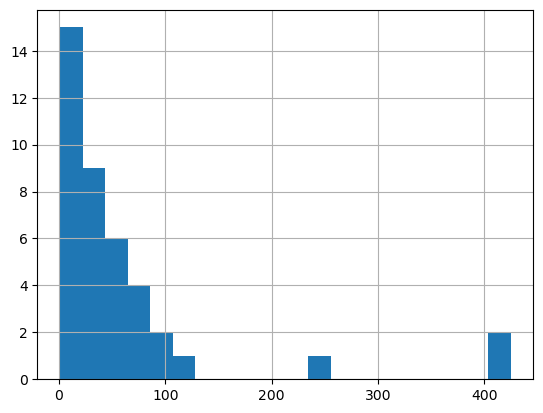

In [90]:
data_raw_lb_baseline_keep_wide.isna().sum().hist(bins=20)

In [91]:
data_raw_lb_baseline_keep_wide.isna().sum().sort_values(ascending=False)

PARAM
b'Epithelial Cells'                              425
b'Bacteria'                                      417
b'Prothrombin Time(sec)'                         254
b'Basophils(10E9/L)'                             112
b'Monocytes(10E9/L)'                             104
b'Eosinophils(10E9/L)'                            98
b'Specific Gravity'                               84
b'Phosphate(mmol/L)'                              68
b'Magnesium(mmol/L)'                              65
b'Urate(\xb5mol/L)'                               65
b'Basophils/Leukocytes(%)'                        64
b'Lymphocytes(10E9/L)'                            63
b'Eosinophils/Leukocytes(%)'                      60
b'pH'                                             56
b'Chloride(mmol/L)'                               55
b'Monocytes/Leukocytes(%)'                        53
b'Glucose(mmol/L)'                                42
b'Activated Partial Thromboplastin Time(sec)'     40
b'Blood Urea Nitrogen(mmol/L)'          

## Check vital signs

In [92]:
data_raw_vs['PARAM'].unique()

array([b'Systolic Blood Pressure (mmHg)',
       b'Diastolic Blood Pressure (mmHg)', b'Pulse Rate (beats/min)',
       b'Height (cm)', b'Weight (kg)', b'Respiratory Rate(/min)',
       b'Body Surface Area (m^2)', b'Temperature (\xb0C)', nan],
      dtype=object)

In [93]:
data_raw_vs_baseline = data_raw_vs.loc[data_raw_vs['BASE'].notna(),:]

In [94]:
data_raw_vs_baseline.groupby('PARAM')['SUBJID'].value_counts()


PARAM                       SUBJID     
b'Body Surface Area (m^2)'  b'284-7887'    16
                            b'014-7886'    15
                            b'024-7885'    15
                            b'034-7808'    15
                            b'034-7882'    15
                                           ..
b'Weight (kg)'              b'428-7802'     2
                            b'495-7881'     2
                            b'497-7886'     2
                            b'586-7807'     2
                            b'721-7881'     2
Name: count, Length: 4244, dtype: int64

In [95]:
data_raw_vs_baseline.groupby(['PARAM','SUBJID'])['BASE'].nunique().sort_values()

PARAM                              SUBJID     
b'Body Surface Area (m^2)'         b'001-7881'    1
b'Systolic Blood Pressure (mmHg)'  b'146-7850'    1
                                   b'146-7852'    1
                                   b'146-7853'    1
                                   b'146-7854'    1
                                                 ..
b'Height (cm)'                     b'506-7882'    1
                                   b'506-7884'    1
                                   b'506-7886'    1
                                   b'470-7882'    1
b'Weight (kg)'                     b'981-7886'    1
Name: BASE, Length: 4244, dtype: int64

In [96]:
selector = (
    data_raw_vs_baseline['PARAM'] == b'Weight (kg)'
) & (
    data_raw_vs_baseline['SUBJID'] == b'428-7802'
)

data_raw_vs_baseline.loc[
    selector, 
    ['SUBJID', 'PARAM','BASE', 'ADY']
]

,SUBJID,PARAM,BASE,ADY
39330,b'428-7802',b'Weight (kg)',58.4,-6.0
39342,b'428-7802',b'Weight (kg)',58.4,1.0


In [97]:
data_raw_vs_baseline_cleaned = data_raw_vs_baseline.groupby(['PARAM','SUBJID'])['BASE'].apply(lambda x: x.iloc[0]).reset_index()

In [98]:
data_raw_vs_baseline_cleaned_wide = data_raw_vs_baseline_cleaned.pivot(index='SUBJID', columns='PARAM', values='BASE')

In [99]:
data_raw_vs_baseline_cleaned_wide.shape

(540, 8)

In [100]:
data_raw_vs_baseline_cleaned_wide.isna().sum()

PARAM
b'Body Surface Area (m^2)'             0
b'Diastolic Blood Pressure (mmHg)'     4
b'Height (cm)'                        34
b'Pulse Rate (beats/min)'              4
b'Respiratory Rate(/min)'             26
b'Systolic Blood Pressure (mmHg)'      4
b'Temperature (\xb0C)'                 4
b'Weight (kg)'                         0
dtype: int64

In [101]:
df_interest_raw_vtsgn = data_raw_vs_baseline_cleaned_wide.copy()

## Merge all data

In [102]:
df_interest_raw_mh_filled = df_interest_raw_mh.fillna(1)
df_interest_raw_mh_wide = df_interest_raw_mh_filled.pivot(index='SUBJID', columns='MHBODSYS', values='MHTOXGR_max')
df_interest_raw_mh_wide = df_interest_raw_mh_wide.fillna(0)

In [103]:
df_interest_raw_demo.shape

(549, 17)

In [104]:
df_interest_raw_traj

,SUBJID,AEDY,AETOXGR_max
0,b'001-7881',0.0,0.0
1,b'001-7881',15.0,2.0
2,b'001-7881',30.0,2.0
0,b'001-7882',0.0,0.0
1,b'001-7882',2.0,2.0
...,...,...,...
6,b'981-7886',63.0,3.0
7,b'981-7886',78.0,3.0
8,b'981-7886',90.0,3.0
9,b'981-7886',98.0,3.0


In [105]:
len(set(df_interest_raw_demo.index) - set(df_interest_raw_traj['SUBJID']))

48

In [106]:
subj_missing_mh  = set(df_interest_raw_demo.index) - set(df_interest_raw_mh_wide.index)
len(subj_missing_mh)

14

In [107]:
subj_missing_vtsgn = set(df_interest_raw_demo.index) - set(df_interest_raw_vtsgn.index)
len(subj_missing_vtsgn)

9

In [108]:
df_demo_mh_vtsgn = df_interest_raw_demo.join(
    df_interest_raw_mh_wide,
    how='left'
).join(
    df_interest_raw_vtsgn,
    how='left'
)

In [109]:
def add_ae_less_subj(df_traj, subj_ae_less, last_obs_dict):
    add_rows = []
    for subj in subj_ae_less:
        max_time = last_obs_dict[subj]
        max_grade = 0
        add_rows.append(
            {
                'SUBJID': subj,
                'AEDY': max_time,
                'AETOXGR_max': max_grade
            }
        )
        add_rows.append(
            {
                'SUBJID': subj,
                'AEDY': 0,
                'AETOXGR_max': max_grade
            }
        )
    add_rows = pd.DataFrame(add_rows)
    return pd.concat([df_traj, add_rows]).sort_values(['SUBJID','AEDY'])

def add_last_obs(df_traj, last_obs_dict):
    add_rows = []
    for subj, df in df_traj.groupby('SUBJID'):
        df = df.sort_values('AEDY')
        max_time = last_obs_dict[subj]
        if (df['AEDY'] < max_time).all():
            add_rows.append(
                {
                  'SUBJID': subj,
                  'AEDY': max_time,
                  'AETOXGR_max': df['AETOXGR_max'].iloc[-1]
                }
            )
    add_rows = pd.DataFrame(add_rows)
    return pd.concat([df_traj, add_rows]).sort_values(['SUBJID','AEDY'])

last_obs_dict = end_eval_day.apply(lambda x: x.days).to_dict()
df_traj_final = add_last_obs(df_interest_raw_traj, last_obs_dict)
df_traj_final = add_ae_less_subj(
    df_interest_raw_traj, 
    set(df_demo_mh_vtsgn.index) - set(df_interest_raw_traj['SUBJID']), 
    last_obs_dict
)

## Association between AE development pattern and any covars?

#### Cluster the trajectories

In [110]:
def get_traj_summary(df_single_traj):
    row = dict()
    row['g_max'] = df_single_traj['AETOXGR_max'].max()
    selector = df_single_traj['AETOXGR_max'] == row['g_max']
    row['t_reach_g_max'] = df_single_traj.loc[selector, 'AEDY'].min()
    row['censor_t'] = df_single_traj['AEDY'].max()
    return pd.Series(row)
df_traj_final_summary = df_traj_final.groupby('SUBJID').apply(get_traj_summary)

/tmp/ipykernel_23295/2082121799.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_traj_final_summary = df_traj_final.groupby('SUBJID').apply(get_traj_summary)


In [111]:
df_traj_final_summary.describe()

,g_max,t_reach_g_max,censor_t
count,549.000000,549.000000,549.000000
mean,2.349727,39.238616,83.382514
std,1.145327,37.804958,46.159942
min,0.000000,0.000000,0.000000
25%,2.000000,8.000000,43.000000
50%,2.000000,24.000000,90.000000
75%,3.000000,65.000000,120.000000
max,5.000000,151.000000,251.000000


In [112]:
df_traj_final_summary_normed = (df_traj_final_summary - df_traj_final_summary.mean())/df_traj_final_summary.std()

In [113]:
df_traj_final_summary_normed

,g_max,t_reach_g_max,censor_t
SUBJID,,,
b'001-7881',-0.305351,-0.641149,-1.156468
b'001-7882',1.440875,-0.641149,0.923257
b'006-7880',1.440875,-0.455988,0.836602
b'008-7881',-1.178464,-0.932116,-0.463227
b'011-7808',0.567762,-0.641149,0.381662
...,...,...,...
b'780-7886',-1.178464,-0.932116,-1.719727
b'782-7881',0.567762,-0.482440,-0.528218
b'782-7886',-0.305351,-0.905665,-1.308115


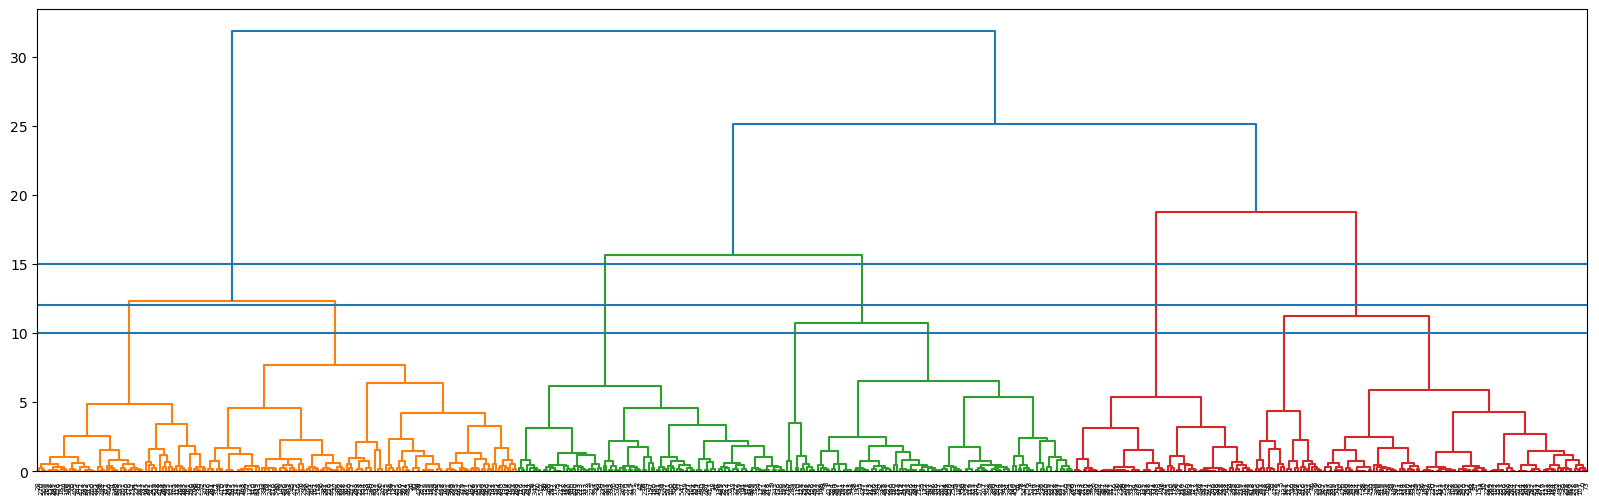

In [114]:
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from scipy.spatial.distance import pdist

pdist_out = pdist(df_traj_final_summary_normed, metric='euclidean')
Z = linkage(pdist_out, 'ward')
ig = plt.figure(figsize=(20, 6))
dn = dendrogram(Z)
for y in [10, 12, 15]:
    plt.axhline(y)
plt.show()

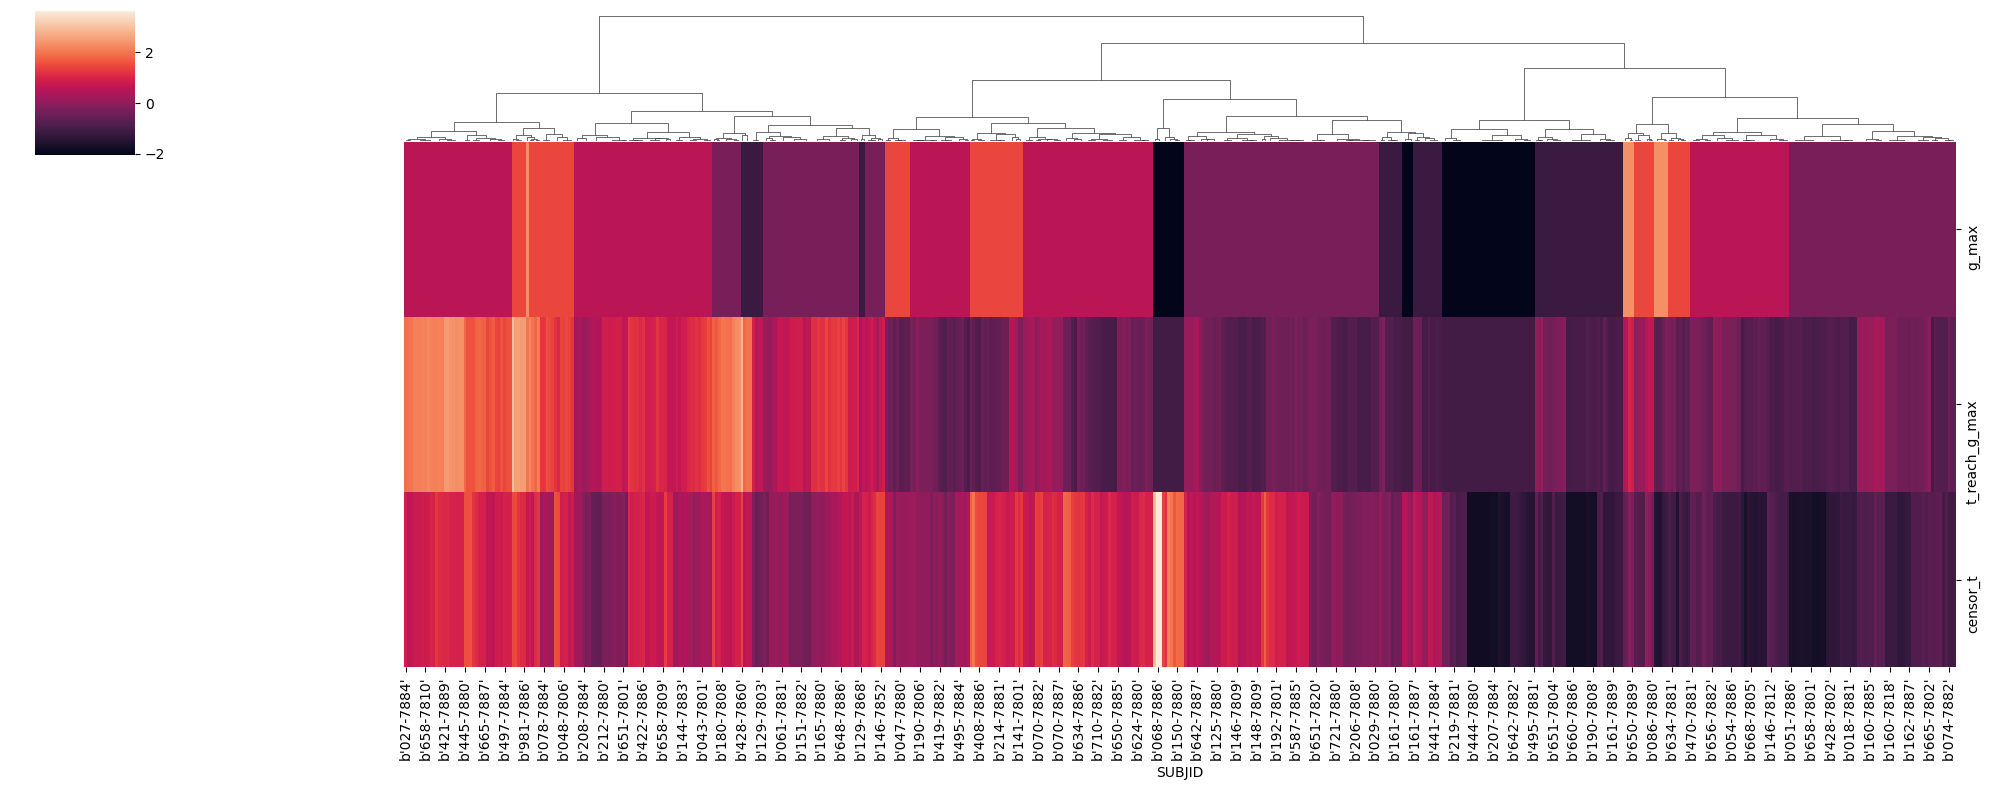

In [115]:
clustergrid = sns.clustermap(
    data=df_traj_final_summary_normed.T,
    row_cluster=False,
    method='ward',
    metric='euclidean',
    figsize=(20, 8)
)

In [116]:
clusters = cut_tree(Z, height=15)

In [117]:
df_traj_final_summary_clust = df_traj_final_summary.copy()
df_traj_final_summary_clust['cluster'] = clusters.flatten()


In [118]:
df_traj_clust_analysis = df_demo_mh_vtsgn.copy()
df_traj_clust_analysis['traj_clust'] = df_traj_clust_analysis.index.map(df_traj_final_summary_clust['cluster'].to_dict())

<Axes: ylabel='SUBJID'>

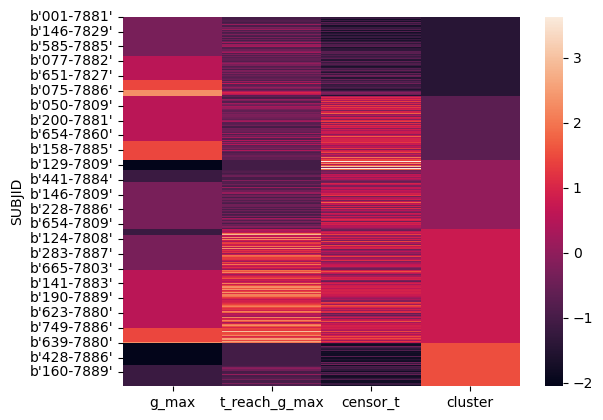

In [119]:
df = (df_traj_final_summary_clust - df_traj_final_summary_clust.mean())/df_traj_final_summary_clust.std()
df = df.sort_values(['cluster', 'g_max'])
sns.heatmap(df)

#### Check for NAs and exclude subjects with lots of missing values

In [120]:
df_traj_clust_analysis.isna().mean(axis=0).sort_values()

AGE                                                                       0.000000
ECOGLGFL                                                                  0.000000
HISCYTFL                                                                  0.000000
traj_clust                                                                0.000000
RACE                                                                      0.000000
SEX                                                                       0.000000
DISSTGFL                                                                  0.001821
ECOGBL                                                                    0.001821
SMKB                                                                      0.001821
BSABL                                                                     0.003643
WBCCAT1                                                                   0.003643
HGBCAT1                                                                   0.003643
PLTC

In [121]:
prop_na_per_subj = df_traj_clust_analysis.isna().mean(axis=1)

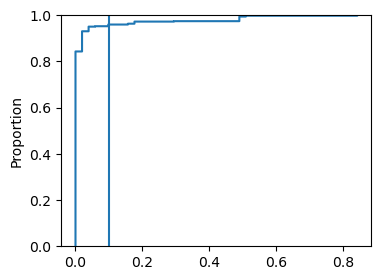

In [122]:
fig, ax = plt.subplots(1,1, figsize=(4, 3))
sns.ecdfplot(
    prop_na_per_subj
)
ax.axvline(x=0.1)


In [123]:
prop_na_per_subj.value_counts().sort_index()

0.000000    463
0.019608     48
0.039216     11
0.058824      1
0.098039      4
0.156863      2
0.176471      5
0.294118      1
0.490196     11
0.509804      2
0.843137      1
Name: count, dtype: int64

In [124]:
df_traj_clust_analysis_dense = df_traj_clust_analysis.loc[prop_na_per_subj.index[prop_na_per_subj < 0.05],:].copy()
df_traj_clust_analysis_dense = df_traj_clust_analysis_dense.loc[
    df_traj_clust_analysis_dense['TRTSDT'].notna(),:
]
col_Y = 'traj_clust'
col_X = [i for i in df_traj_clust_analysis_dense.columns if (i != col_Y) and (i not in cols_demo_days_interest)]
n_unique_per_X_col = df_traj_clust_analysis_dense[col_X].nunique()
cols_X_numer = df_traj_clust_analysis_dense[col_X].select_dtypes("number").columns
cols_X_cat = [i for i in col_X if i not in cols_X_numer]

In [125]:
df_traj_clust_analysis_dense.shape

(521, 51)

#### Univar exploratory analysis

In [126]:

least_freq_per_col = df_traj_clust_analysis_dense[cols_X_cat].apply(lambda x: x.value_counts(dropna=False).min())
least_freq_per_col.sort_values()

df_traj_clust_analysis_dense = df_traj_clust_analysis_dense.copy()
cols_to_drop_least_freq = least_freq_per_col.index[least_freq_per_col < 5]
for col in cols_to_drop_least_freq:
    x = df_traj_clust_analysis_dense[col].fillna('NA')
    counts = x.value_counts().sort_values()
    merge_with = counts[counts >= 5].min()
    merge_with = counts.index[counts == merge_with][0]
    rare_cat = counts.index[counts < 5]
    if counts[rare_cat].sum() >= 5:
        selector = x.isin(rare_cat)
        df_traj_clust_analysis_dense.loc[selector, col] = 'merged_cat'
    else:
        selector = x.isin(rare_cat) | (x == merge_with)
        df_traj_clust_analysis_dense.loc[selector, col] = 'merged_cat'
least_freq_per_col = df_traj_clust_analysis_dense[cols_demo_interest_cat].apply(lambda x: x.value_counts(dropna=False).min())
least_freq_per_col.sort_values()

RACE          7
HISTOLG      11
SMKB         24
ETHNIC       52
SEX          87
HGBCAT1     107
WBCCAT1     166
PLTCAT1     240
HISCYTFL    521
DISSTGFL    521
ECOGLGFL    521
dtype: int64

In [127]:
df_traj_clust_analysis_dense[cols_X_cat].nunique(dropna=False)

SEX         2
RACE        4
ETHNIC      2
HISCYTFL    1
DISSTGFL    1
ECOGLGFL    1
SMKB        3
HISTOLG     5
WBCCAT1     2
HGBCAT1     2
PLTCAT1     2
dtype: int64

In [128]:
cols_X_cat = np.array(cols_X_cat)[df_traj_clust_analysis_dense[cols_X_cat].nunique(dropna=False).values > 1]
cols_X_cat

array(['SEX', 'RACE', 'ETHNIC', 'SMKB', 'HISTOLG', 'WBCCAT1', 'HGBCAT1',
       'PLTCAT1'], dtype='<U8')

In [129]:
from scipy.stats.contingency import chi2_contingency
chi2_res = []
for col in cols_X_cat:
    crosstab = pd.crosstab(
        df_traj_clust_analysis_dense[col_Y],
        df_traj_clust_analysis_dense[col]
    )
    res = chi2_contingency(crosstab)
    chi2_res.append(
        {
            'col':col,
            'chi2':res.statistic,
            'pval':res.pvalue,
            'dof':res.dof
        }
    )
chi2_res = pd.DataFrame(chi2_res)

<Axes: xlabel='traj_clust'>

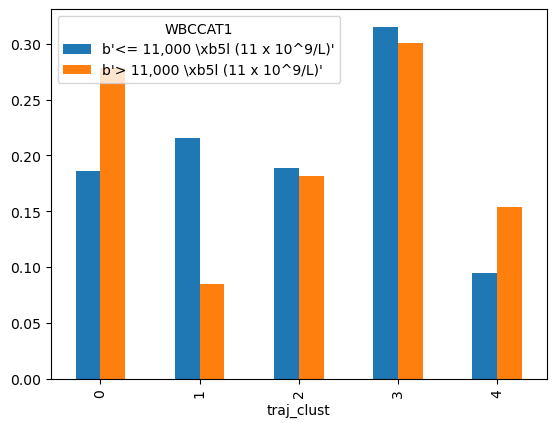

In [130]:
df = pd.crosstab(
    df_traj_clust_analysis['WBCCAT1'],
    df_traj_clust_analysis[col_Y]
).T
df = (df/df.sum())
df.plot(kind='bar')


In [131]:
chi2_res

,col,chi2,pval,dof
0,SEX,6.180530,0.186066,4
1,RACE,17.054553,0.147557,12
2,ETHNIC,4.313475,0.365241,4
3,SMKB,2.859043,0.942889,8
4,HISTOLG,10.955497,0.812224,16
5,WBCCAT1,19.546352,0.000614,4
6,HGBCAT1,13.545265,0.008897,4
7,PLTCAT1,3.375489,0.497061,4


In [132]:
from scipy.stats import f_oneway
corr_res = []
for col in cols_X_numer:
    x = df_traj_clust_analysis_dense[col]
    y = df_traj_clust_analysis_dense[col_Y]

    selector = x.notna() & y.notna()
    x = x[selector]
    y = y[selector]
    res = f_oneway(*[x[y == i] for i in y])
    corr_res.append(
        {
            'col':col,
            'F':res.statistic,
            'pval':res.pvalue
        }
    )
corr_res = pd.DataFrame(corr_res)

/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

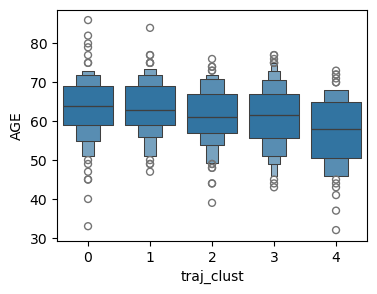

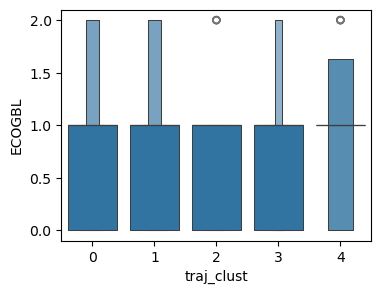

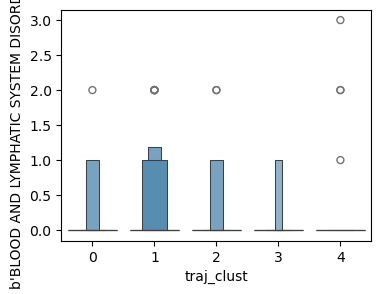

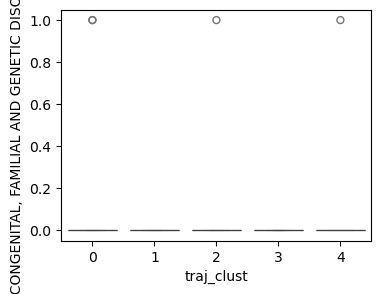

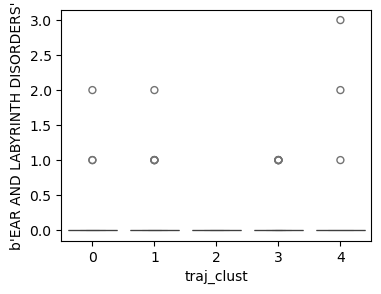

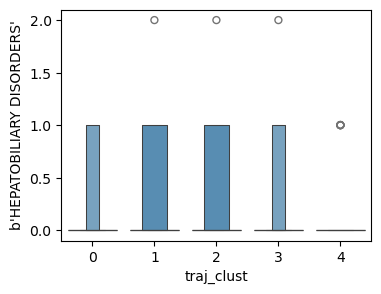

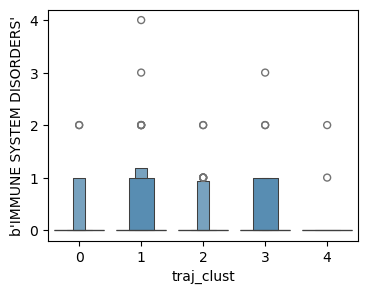

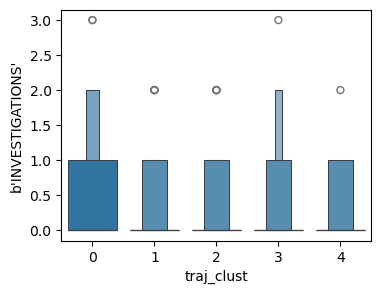

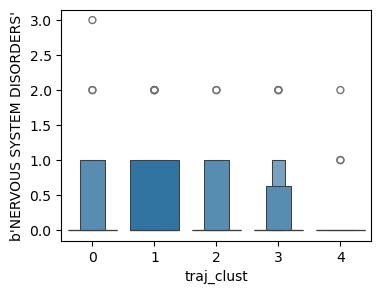

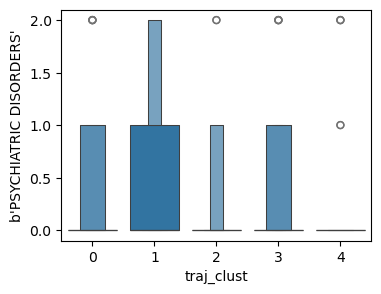

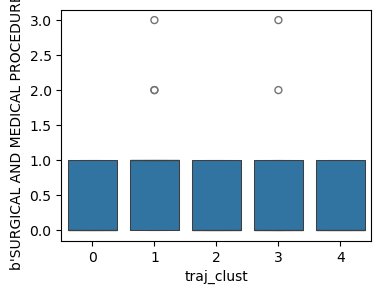

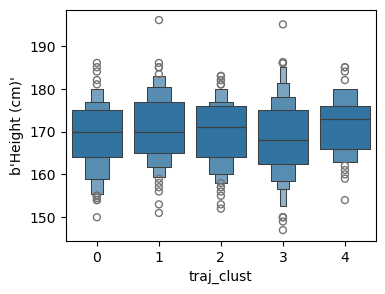

In [133]:
for idx_, row in corr_res.loc[
    corr_res['pval'] < 0.05,:
].iterrows():
    col, chi, pval = row.values
    title = f'{col}, p-val = {pval:.2f}'
    fig, ax = plt.subplots(1,1, figsize=(4, 3))
    sns.boxenplot(
        data=df_traj_clust_analysis_dense,
        x=col_Y,
        y=col
    )

In [134]:
corr_res.sort_values('pval').head()

,col,F,pval
0,AGE,4.755783,3.084741e-244
20,b'NERVOUS SYSTEM DISORDERS',3.591959,7.899859e-148
4,b'BLOOD AND LYMPHATIC SYSTEM DISORDERS',3.015123,1.299819e-103
21,b'PSYCHIATRIC DISORDERS',2.477929,7.165655e-66
12,b'HEPATOBILIARY DISORDERS',1.586503,4.740145e-16


In [135]:
chi2_res.sort_values('pval').head()

,col,chi2,pval,dof
5,WBCCAT1,19.546352,0.000614,4
6,HGBCAT1,13.545265,0.008897,4
1,RACE,17.054553,0.147557,12
0,SEX,6.180530,0.186066,4
2,ETHNIC,4.313475,0.365241,4


In [136]:
cols_X_cat_signal = chi2_res.loc[chi2_res['pval'] < 0.01, 'col']
cols_X_numer_signal = corr_res.loc[corr_res['pval'] < 0.01, 'col']

In [137]:
cols_X_cat_signal

5    WBCCAT1
6    HGBCAT1
Name: col, dtype: object

In [138]:
cols_X_numer_signal

0                                               AGE
2                                            ECOGBL
4           b'BLOOD AND LYMPHATIC SYSTEM DISORDERS'
6     b'CONGENITAL, FAMILIAL AND GENETIC DISORDERS'
7                    b'EAR AND LABYRINTH DISORDERS'
12                       b'HEPATOBILIARY DISORDERS'
13                       b'IMMUNE SYSTEM DISORDERS'
16                                b'INVESTIGATIONS'
20                      b'NERVOUS SYSTEM DISORDERS'
21                         b'PSYCHIATRIC DISORDERS'
27               b'SURGICAL AND MEDICAL PROCEDURES'
31                                   b'Height (cm)'
Name: col, dtype: object

### Binarize cat cols, impute, and visualize

In [139]:
df = df_traj_clust_analysis_dense[cols_X_cat].copy()
df = df.map(lambda x: x.decode('latin1') if isinstance(x, bytes) else x)

In [140]:
df_cols_X_cat_binarized = pd.get_dummies(df[cols_X_cat], drop_first=True)
df_cols_X_num = df_traj_clust_analysis_dense[cols_X_numer]

df_cols_X_numerized = df_cols_X_cat_binarized.join(df_cols_X_num)
df_cols_X_numerized.columns = df_cols_X_numerized.columns.map(lambda x: x.decode('latin1') if isinstance(x, bytes) else x)
cols_X_numerized = sorted(df_cols_X_numerized.columns)
df_cols_X_numerized = df_cols_X_numerized[cols_X_numerized]

In [141]:
df_cols_X_numerized.shape

(521, 51)

In [142]:
from sklearn.impute import KNNImputer
df_cols_X_numerized_imputed = df_cols_X_numerized.copy()
imputer = KNNImputer(n_neighbors=10, weights="distance")
df_cols_X_numerized_imputed = pd.DataFrame(
    imputer.fit_transform(df_cols_X_numerized),
    columns=df_cols_X_numerized.columns,
    index=df_cols_X_numerized.index
)
n_unique_vals_per_col_raw = df_cols_X_numerized.nunique()
cols_discretise = n_unique_vals_per_col_raw.index[n_unique_vals_per_col_raw <= 5]

In [143]:
set(df_cols_X_numerized_imputed[cols_discretise].values.flatten())

{0.0, 1.0, 2.0, 3.0, 4.0}

In [144]:
df_cols_X_numerized_imputed[cols_discretise] = df_cols_X_numerized_imputed[cols_discretise].round(0)

In [145]:
set(df_cols_X_numerized_imputed[cols_discretise].values.flatten())

{0.0, 1.0, 2.0, 3.0, 4.0}

In [146]:
cols_signal_imputed = []
for prefix in cols_X_cat_signal:
    cols_signal_imputed += [i for i in df_cols_X_numerized_imputed.columns if i.startswith(prefix)]
cols_signal_imputed += list(
    cols_X_numer_signal.map(lambda x: x.decode('latin1') if isinstance(x, bytes) else x)
)

In [147]:
X = df_cols_X_numerized_imputed[cols_signal_imputed]

from sklearn.manifold import TSNE as learner
from sklearn.preprocessing import RobustScaler

X_scaled = RobustScaler(unit_variance=False, quantile_range=(10, 90)).fit_transform(X)

embedding = learner(n_components=5, method='exact')
X_transformed = pd.DataFrame(
    embedding.fit_transform(X_scaled),
    index=X.index
)
col_components = [f'Component{i}' for i in X_transformed.columns]
X_transformed.columns = col_components
X_transformed[col_Y] = 'clust' +  X_transformed.index.map(df_traj_clust_analysis_dense[col_Y]).astype(str)

In [148]:
X_transformed.head()

,Component0,Component1,Component2,Component3,Component4,traj_clust
SUBJID,,,,,,
b'001-7881',8.502069,-2.097253,-9.849800,-4.855755,1.151217,clust0
b'001-7882',-5.978769,-13.162554,4.642333,1.451702,-13.562592,clust1
b'006-7880',-1.674497,-1.285985,-12.678932,7.370591,0.748475,clust1
b'008-7881',2.239800,3.582901,0.189331,-3.359584,1.033321,clust2
b'011-7808',-1.559904,-5.386253,-9.869509,6.213571,-2.580040,clust1


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

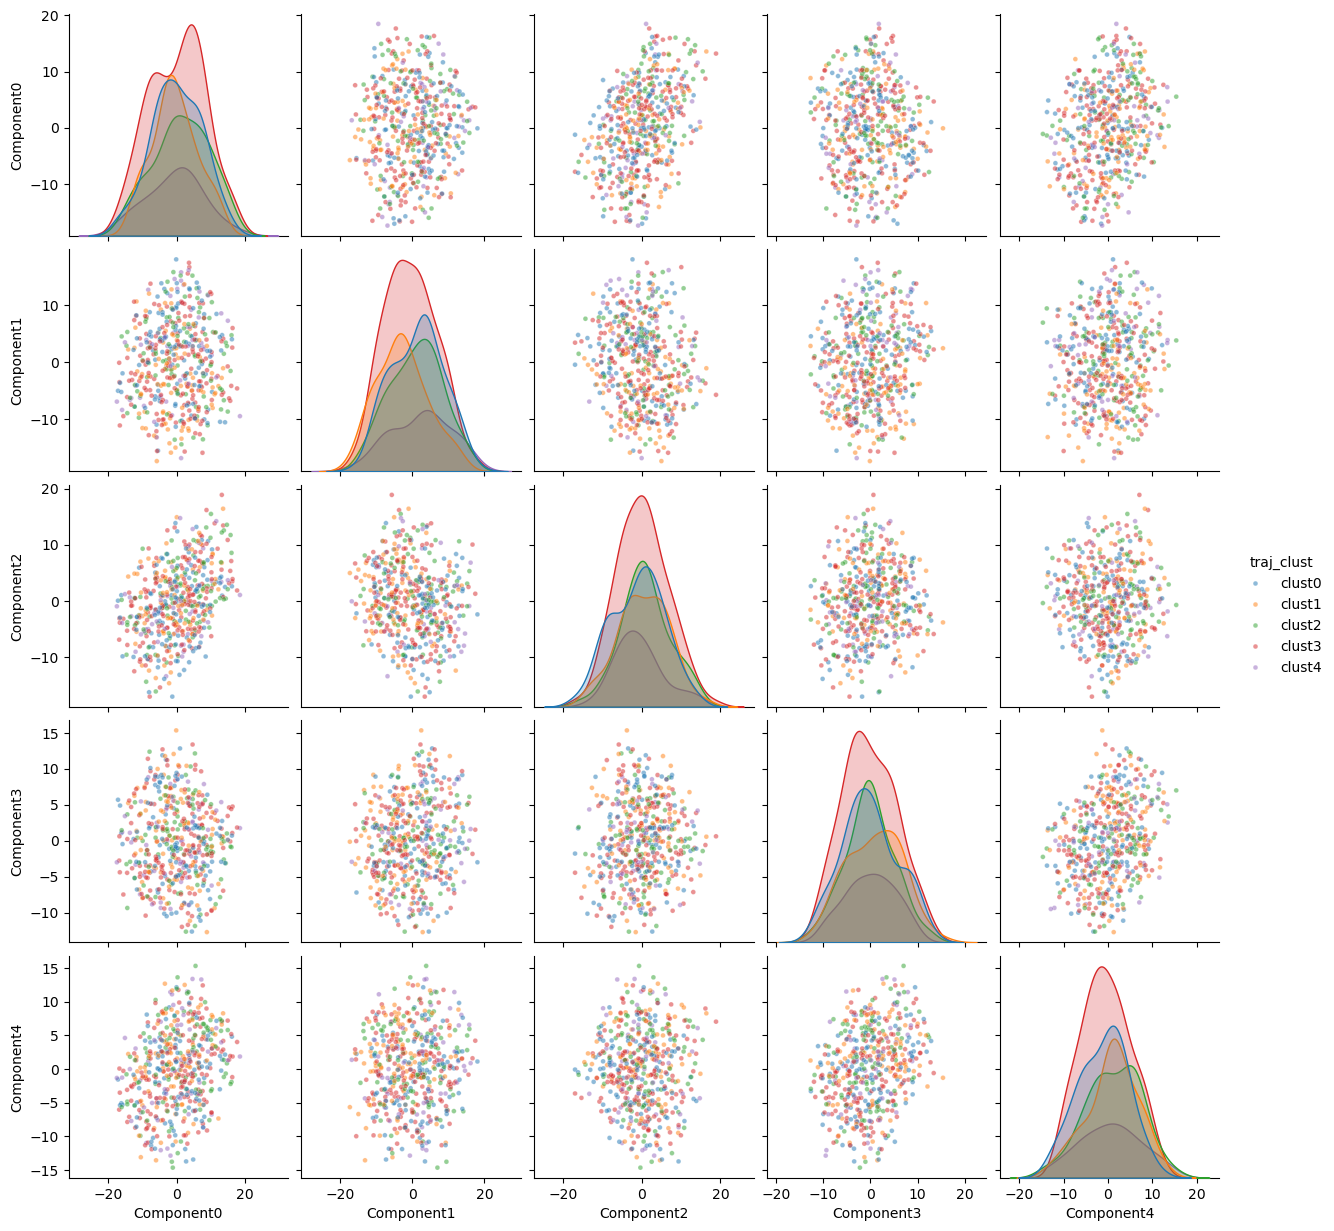

In [149]:
sns.pairplot(
    data=X_transformed,
    vars=col_components,
    hue='traj_clust',
    plot_kws={'alpha':0.5, 's':12},
)

### Write out data tables

In [153]:
df_state_history_sampled_max = df_traj_final.copy()
df_state_history_sampled_max = df_state_history_sampled_max.rename(
    columns={
        'SUBJID':'subject',
        'AEDY':'t',
        'AETOXGR_max':'g_max_by_time'
    }
)
df_state_history_sampled_max = df_state_history_sampled_max.loc[
    df_state_history_sampled_max['subject'].isin(df_cols_X_numerized_imputed.index),:
]

In [154]:
df_features = df_cols_X_numerized_imputed.copy()
df_features.columns = [f'feat__{i}' for i in df_features.columns]
df_features = df_features.reset_index().rename(columns={'SUBJID':'subject'})

In [155]:
df_features.to_csv(os.path.join(OUTPUT_DIR,'df_features.csv'))
df_state_history_sampled_max.to_csv(os.path.join(OUTPUT_DIR,'df_state_history_sampled_max.csv'))